In [ ]:
# Install spacy/transformers

!pip install --upgrade pip
!pip install -U spacy spacy-curated-transformers
!python -m spacy download en_core_web_trf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 25.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
INFO: pip is looking at multiple versions of spacy-curated-transformers to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 28.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [spacy-curated-transformers]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 56.4 MB/s  0:00:08
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Use GPU

import torch
import spacy

if torch.cuda.is_available():
    spacy.require_gpu()
else:
    spacy.prefer_gpu()
nlp = spacy.load("en_core_web_trf")

In [ ]:
# Load in datasets

import pandas as pd
import numpy as np
df_hawk = pd.read_csv("https://raw.githubusercontent.com/refbank/refbank-import/refs/heads/main/harmonized_data/hawkins2020_characterizing_cued/messages.csv")
df_boyce = pd.read_csv("https://raw.githubusercontent.com/refbank/refbank-import/refs/heads/main/harmonized_data/boyce2024_interaction/messages.csv")

In [ ]:
num_new_cols = 768

# Add symmantic definition in 768 vector space for each message to inputed dataframe
def addEmbeddings(df_in):
  lst_of_list_with_embeds = []

  # Go through each message
  texts = df_in["text"].tolist()  # list of all texts
  docs = list(nlp.pipe(texts, batch_size=16))
  for doc in docs:
      tensor = doc._.trf_data.last_hidden_layer_state
      dat = tensor.data
      means = np.mean(dat, axis=0)
      lst_of_list_with_embeds.append(means)
  embeddings_list_cpu = []

  # Convert to datafrane
  for embed_lst in lst_of_list_with_embeds:
      if hasattr(embed_lst, "detach"):
          embeddings_list_cpu.append(embed_lst.detach().cpu().numpy())
      elif hasattr(embed_lst, "get"):
          embeddings_list_cpu.append(embed_lst.get())
      else:
          embeddings_list_cpu.append(embed_lst)
  embeddings_array = np.vstack(embeddings_list_cpu).astype(np.float64)
  new_df = pd.DataFrame(embeddings_array,
                        columns=[f"dim space: {num}" for num in range(1, num_new_cols + 1)],
                        index=df_in.index)


  df_out = pd.concat([df_in, new_df], axis=1)
  df_out["message_irrelevant"] = df_out["message_irrelevant"].fillna(False).astype(bool)
  return df_out


df_hawk_ed = addEmbeddings(df_hawk)
df_boyce_ed = addEmbeddings(df_boyce)


/tmp/ipython-input-1997660812.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_out["message_irrelevant"] = df_out["message_irrelevant"].fillna(False).astype(bool)
/tmp/ipython-input-1997660812.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_out["message_irrelevant"] = df_out["message_irrelevant"].fillna(False).astype(bool)


In [ ]:
# Save dataframes

df_hawk_ed.to_csv("Hawkins 768 edited 3.csv")
df_boyce_ed.to_csv("Boyce 768 edited 3.csv")

In [ ]:
# Load in dataframes, if necesary
# import pandas as pd
# import numpy as np
# df_hawk_ed = pd.read_csv("Hawkins 768 edited 3.csv")
# df_boyce_ed = pd.read_csv("Boyce 768 edited 3.csv")
# num_new_cols = 768

In [ ]:
# Analyze class imbalances

print(df_hawk_ed["message_irrelevant"].value_counts(normalize=True))
print(df_boyce_ed["message_irrelevant"].value_counts(normalize=True))


message_irrelevant
False    0.887435
True     0.112565
Name: proportion, dtype: float64
message_irrelevant
False    0.716187
True     0.283813
Name: proportion, dtype: float64


In [ ]:
# Fit models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


cols = [f"dim space: {i}" for i in range(1, num_new_cols + 1)] # 768 columns with embeddings

X_train = df_hawk_ed[cols]
y_train = df_hawk_ed["message_irrelevant"]
X_test = df_boyce_ed[cols]
y_test = df_boyce_ed["message_irrelevant"]

RFC_model = RandomForestClassifier()
RFC_model.fit(X_train, y_train)



LR_model = LogisticRegression(max_iter=15000)
LR_model.fit(X_train, y_train)

LogisticRegression(max_iter=15000)

In [ ]:
# Have models make predictions

RFC_pred = (RFC_model.predict_proba(X_test)[:,1])
RFC_pred_bool = (RFC_pred >= 0.5).astype(bool) # Can adjust the 0.5 value to get better recall on 'message_relevant' class, but doesn't affect ROC curve
print("RFC")
print(classification_report(y_test, RFC_pred_bool))

print("LR")
LR_pred = (LR_model.predict_proba(X_test)[:,1])
LR_pred_bool = (LR_pred  > 0.5).astype(bool) # Can adjust the 0.5 value to get better recall on 'message_relevant' class, but doesn't affect ROC curve
print(classification_report(y_test, LR_pred_bool))

# I decided to comment out KNN because it did poorly
# print("KNN")
# KNN_pred = (KNN_model.predict_proba(X_test)[:,1])
# KNN_pred_bool = (KNN_pred  > 0.5).astype(bool)
# print(classification_report(y_test, KNN_pred_bool))


RFC
              precision    recall  f1-score   support

       False       0.87      0.95      0.91     51009
        True       0.83      0.65      0.73     20214

    accuracy                           0.86     71223
   macro avg       0.85      0.80      0.82     71223
weighted avg       0.86      0.86      0.86     71223

LR
              precision    recall  f1-score   support

       False       0.90      0.94      0.92     51009
        True       0.82      0.72      0.77     20214

    accuracy                           0.88     71223
   macro avg       0.86      0.83      0.84     71223
weighted avg       0.87      0.88      0.87     71223



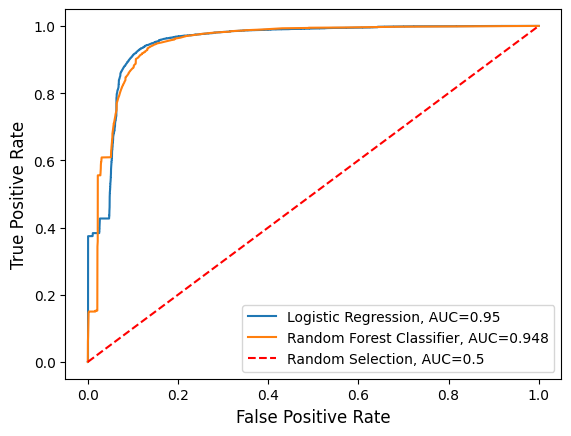

In [ ]:
# Build graphs and save results

from sklearn import metrics
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

LR_fpr, LR_tpr, LR_thresholds = metrics.roc_curve(y_test, LR_pred)
LR_auc = round(metrics.auc(LR_fpr, LR_tpr), 3)
plt.plot(LR_fpr, LR_tpr, label=f"Logistic Regression, AUC={LR_auc}")

RFC_fpr, RFC_tpr, RFC_thresholds = metrics.roc_curve(y_test, RFC_pred)
RFC_auc = round(metrics.auc(RFC_fpr, RFC_tpr), 3)
plt.plot(RFC_fpr, RFC_tpr, label=f"Random Forest Classifier, AUC={RFC_auc}")

# I decided to comment out KNN because it did poorly
# KNN_fpr, KNN_tpr, KNN_thresholds = metrics.roc_curve(y_test, KNN_pred)
# KNN_auc = round(metrics.auc(KNN_fpr, KNN_tpr), 3)
# plt.plot(KNN_fpr, KNN_tpr, label=f"KNN, AUC={KNN_auc}")

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Selection, AUC=0.5')

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend()
plt.savefig("Train_Hawk Test_Boyce ROC Curve (5).png")


